# EEG Lab — Notebook 1/5
## Data preparation and simulation of the *oddball* paradigm (P300)

**Goals of this notebook**
- Understand the *oddball* paradigm and the **P300** component
- Discover the format of EEG data recorded with the **OpenBCI Cyton** (8 channels, **250 Hz**)
- Understand how **stimuli (triggers)** are recorded on the **digital channel D11**
- Generate a **realistic simulated dataset** to use as a *fallback* if live recording fails

---

### The *oddball* paradigm in one sentence
The subject is presented with a long sequence of stimuli: most are **frequent** (the *standards*, ~80%), a few are **rare** (the *targets* / *deviants*, ~20%). The subject must **detect and count the targets**. The brain reacts to rare targets with a late positive wave, the **P300**, maximal ~300–500 ms after the stimulus, over **centro-parietal** electrodes (Pz, Cz).

> Throughout this series of 5 notebooks, we will use either the **real data** recorded in the lab, or this **simulated data**. Both have exactly the same format, so the code works in either case.


### 1. Import the libraries
We always start a Python script by importing the tools we need.

In [ ]:
import numpy as np                 # numerical computing (arrays of numbers)
import matplotlib.pyplot as plt    # plotting graphs
from scipy.signal import butter, filtfilt  # to color the simulated noise

print("Libraries imported successfully!")

Libraries imported successfully!


### 2. The hardware parameters
The OpenBCI Cyton **without the Daisy module** records **8 channels** at **250 Hz** (250 samples per second per channel).

⚠️ Note: if we added the Daisy module (16 channels), the sampling rate would be halved (125 Hz). Here we are using the **Cyton alone → 250 Hz**. This value must be respected everywhere.

In [ ]:
FS = 250  # sampling rate in Hz (Cyton alone, no Daisy)

# The 8 electrodes, named according to the international 10-20 system
CHANNELS = ['Fz', 'Cz', 'Pz', 'Oz', 'C3', 'C4', 'P3', 'P4']

print(f"Sampling rate: {FS} Hz")
print(f"Number of EEG channels: {len(CHANNELS)}")
print(f"Electrodes: {CHANNELS}")
print(f"Duration of one sample: {1000/FS:.1f} ms")

Sampling rate: 250 Hz
Number of EEG channels: 8
Electrodes: ['Fz', 'Cz', 'Pz', 'Oz', 'C3', 'C4', 'P3', 'P4']
Duration of one sample: 4.0 ms


### 3. How are stimuli recorded? The *trigger* channel (D11)

To analyze an ERP, the EEG alone is not enough: we need to know **at exactly which moment** each stimulus was presented, and **of which type** it was (standard or target).

With the Cyton, we connect the stimulation machine to the **digital port D11**. At each stimulus, a pulse is sent on this channel. We therefore record an extra channel, the **trigger channel**, which is:
- `0` most of the time (nothing happens),
- `1` at the exact moment of a **standard** stimulus,
- `2` at the exact moment of a **target** stimulus.

Our dataset will therefore have **9 rows**: the 8 EEG channels + 1 trigger channel.

### 4. The simulated-data generator

The function below builds a realistic oddball recording. **You don't need to understand all of it right now** — what matters is knowing what it produces as output. We come back to it in more detail throughout the labs.

What it simulates:
- a **background EEG noise** (spontaneous brain activity + a bit of alpha rhythm),
- a small **N100** wave after each stimulus (early sensory response),
- a **P300** wave added at ~350 ms, **much larger for targets** than for standards,
- a **realistic topography**: P300 maximal at Pz and Cz.

In [ ]:
def simulate_oddball(fs=250, n_trials=200, p_target=0.2, channels=None, seed=42):
    """
    Simulate an oddball EEG recording.

    Parameters
    ----------
    fs : sampling rate (Hz)
    n_trials : total number of stimuli presented
    p_target : proportion of target (rare) stimuli
    channels : list of electrode names
    seed : to make the random draw reproducible

    Returns
    -------
    data : array (9, n_samples) = 8 EEG channels + 1 trigger channel
    channels : the list of electrode names
    fs : the sampling rate
    """
    rng = np.random.default_rng(seed)
    if channels is None:
        channels = ['Fz', 'Cz', 'Pz', 'Oz', 'C3', 'C4', 'P3', 'P4']
    n_ch = len(channels)

    isi = 0.8                          # interval between two stimuli (s)
    n_samp_trial = int(isi * fs)       # samples per trial
    n_samples = n_trials * n_samp_trial
    t = np.arange(n_samples) / fs

    # --- Background EEG noise ---
    eeg = rng.standard_normal((n_ch, n_samples))
    b, a = butter(2, 30/(fs/2), 'low')        # remove high frequencies
    eeg = filtfilt(b, a, eeg, axis=1) * 15    # amplitude ~15 uV
    eeg += 8*np.sin(2*np.pi*10*t)[None, :] * rng.uniform(0.3, 1, (n_ch, 1))  # alpha

    # --- Which trials are targets? ---
    is_target = rng.random(n_trials) < p_target
    trig = np.zeros(n_samples)
    onsets = np.arange(n_trials)*n_samp_trial + int(0.1*fs)

    # Topographic weights: the P300 is maximal centro-parietally
    weights = {'Fz':0.5,'Cz':0.9,'Pz':1.0,'Oz':0.3,'C3':0.6,'C4':0.6,'P3':0.8,'P4':0.8}

    def p300_wave(amp, lat, width, n):
        tt = np.arange(n)/fs
        return amp*np.exp(-((tt-lat)**2)/(2*width**2))

    def n100_wave(amp, n):
        tt = np.arange(n)/fs
        return -amp*np.exp(-((tt-0.1)**2)/(2*0.03**2))

    n_post = int(0.8*fs)
    for i, onset in enumerate(onsets):
        trig[onset] = 2 if is_target[i] else 1     # code 2=target, 1=standard
        for ci, ch in enumerate(channels):
            seg = slice(onset, min(onset+n_post, n_samples))
            L = seg.stop - seg.start
            w = n100_wave(3, L)
            p300_amp = 6 if is_target[i] else 1.5   # target >> standard
            w = w + p300_wave(p300_amp*weights[ch], 0.35, 0.06, L)
            eeg[ci, seg] += w

    data = np.vstack([eeg, trig[None, :]])   # stack EEG + triggers
    return data, channels, fs

print("Simulation function defined.")

Simulation function defined.


### 5. Generate and inspect the data

In [ ]:
data, channels, fs = simulate_oddball(fs=FS, n_trials=200, p_target=0.2, channels=CHANNELS)

print(f"Shape of the data array: {data.shape}")
print(f"  -> {data.shape[0]} rows: {len(channels)} EEG channels + 1 trigger channel")
print(f"  -> {data.shape[1]} samples per channel")
print(f"  -> i.e. {data.shape[1]/fs:.1f} seconds of recording")

# How many stimuli of each type?
trig_channel = data[-1]   # the last row = the triggers
n_standard = int(np.sum(trig_channel == 1))
n_target   = int(np.sum(trig_channel == 2))
print(f"\nStandard stimuli (code 1): {n_standard}")
print(f"Target stimuli (code 2)  : {n_target}")
print(f"Proportion of targets    : {100*n_target/(n_standard+n_target):.0f}%")

Shape of the data array: (9, 40000)
  -> 9 rows: 8 EEG channels + 1 trigger channel
  -> 40000 samples per channel
  -> i.e. 160.0 seconds of recording

Standard stimuli (code 1): 169
Target stimuli (code 2)  : 31
Proportion of targets    : 16%


### 6. Visualize an excerpt of the signal and the triggers
Let's plot the first 10 seconds of the Pz electrode, overlaying the stimulus onsets.

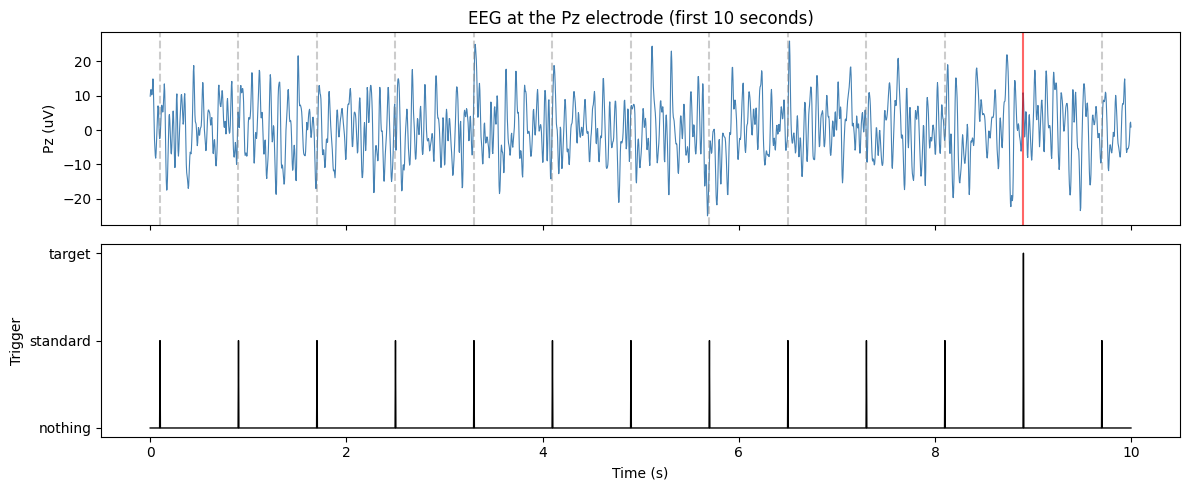

Gray lines = standard stimuli | red lines = target stimuli


In [ ]:
duration = 10  # seconds
n = int(duration * fs)
t = np.arange(n) / fs

idx_pz = channels.index('Pz')
sig_pz = data[idx_pz, :n]
trig = data[-1, :n]

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax[0].plot(t, sig_pz, color='steelblue', lw=0.8)
ax[0].set_ylabel('Pz (uV)')
ax[0].set_title("EEG at the Pz electrode (first 10 seconds)")

# mark the stimuli
for onset in np.where(trig == 1)[0]:
    ax[0].axvline(onset/fs, color='gray', ls='--', alpha=0.4)
for onset in np.where(trig == 2)[0]:
    ax[0].axvline(onset/fs, color='red', ls='-', alpha=0.6)

ax[1].plot(t, trig, color='black', lw=1)
ax[1].set_ylabel('Trigger')
ax[1].set_xlabel('Time (s)')
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(['nothing', 'standard', 'target'])

plt.tight_layout()
plt.show()

print("Gray lines = standard stimuli | red lines = target stimuli")

### 7. Save the data
We save the data to a `.npy` file (NumPy format) to reuse it in the following notebooks.

In [ ]:
np.save('oddball_data.npy', data)
# We also save the useful metadata
np.save('oddball_channels.npy', np.array(channels))

print("Data saved to 'oddball_data.npy'")
print("You can now move on to Notebook 2.")

Data saved to 'oddball_data.npy'
You can now move on to Notebook 2.


---
### ✏️ Exercises
1. Rerun the simulation with `p_target=0.1` (even rarer targets). How many targets do you get?
2. Change the `seed` (e.g. `seed=7`): does the noise change? And the number of targets?
3. Plot the `Oz` electrode instead of `Pz`. Do you see the same thing?

### 🔑 Key takeaways
- The oddball paradigm contrasts **frequent (standard)** and **rare (target)** stimuli.
- The **P300** is a positive wave ~300–500 ms, maximal **centro-parietally**.
- Stimuli are recorded on a **trigger channel** (D11 port): `1`=standard, `2`=target.
- Our data has shape **(9 rows, N samples)** sampled at **250 Hz**.
